# Lab 08

**ID:** 22302421

**Name:** Nguyễn Phúc Minh Châu

### 1. Upload data file and display the first 5 lines

In [25]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('DA08_sales_data.csv')
df.head(5)

,date,region,product,price,quantity,customer_type,revenue
0,2025-01-01,East,Tablet,796,5,Returning,3980
1,2025-01-02,West,Tablet,601,3,New,1803
2,2025-01-03,North,Laptop,480,9,New,4320
3,2025-01-04,East,Laptop,906,4,Returning,3624
4,2025-01-05,East,Phone,1422,5,New,7110


### 2. Draw a line chart: Total revenue over time

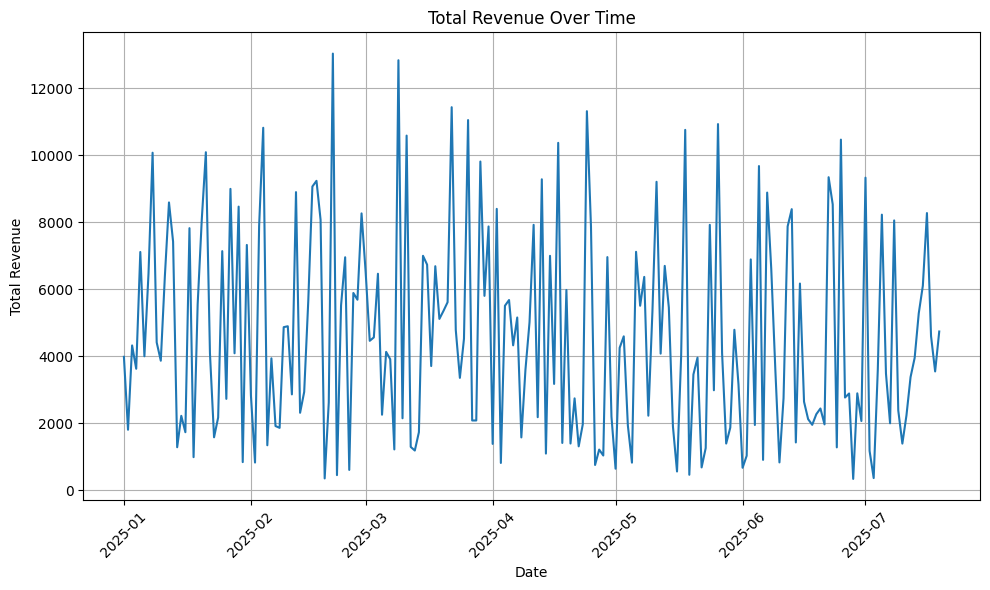

In [26]:
df['date'] = pd.to_datetime(df['date'])
revenue_over_time = df.groupby('date')['revenue'].sum()

plt.figure(figsize=(10, 6))
plt.plot(revenue_over_time.index, revenue_over_time.values)
plt.title('Total Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

### 3. Draw a bar chart:  total revenue by region

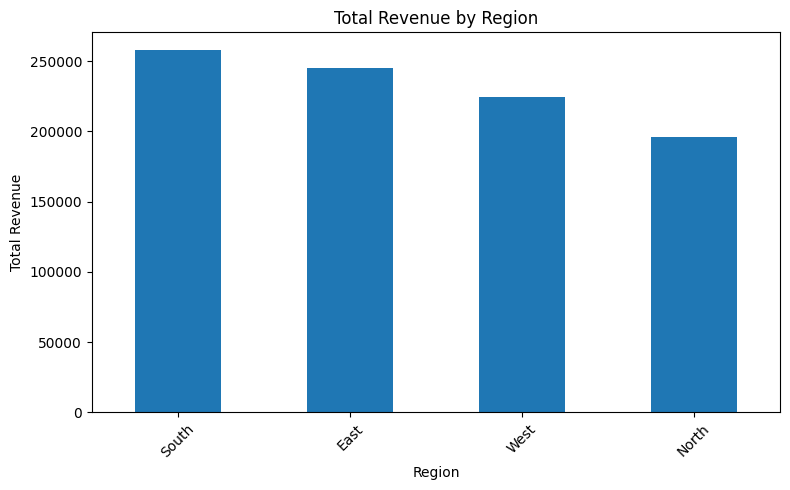

In [27]:
df['region'] = df['region'].str.strip()
revenue_by_region = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
revenue_by_region.plot(kind='bar')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4. Plot a histogram: revenue distribution

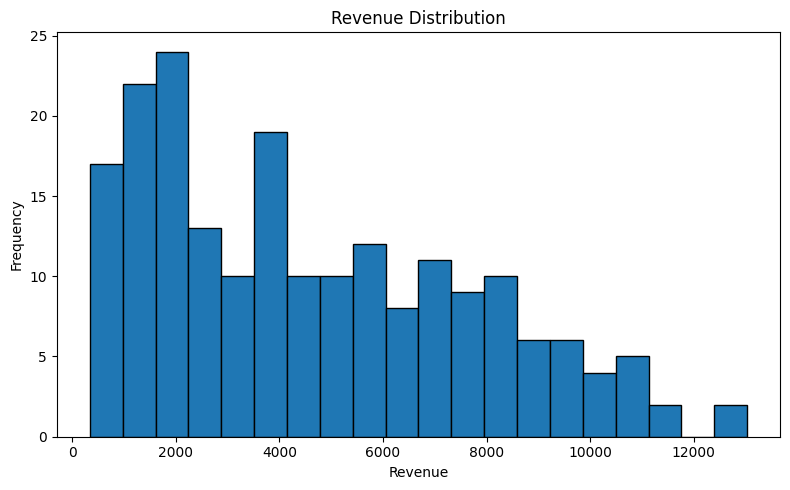

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(df['revenue'], bins=20, edgecolor='black')
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 5. Compare revenue between products over time (multi-line chart).

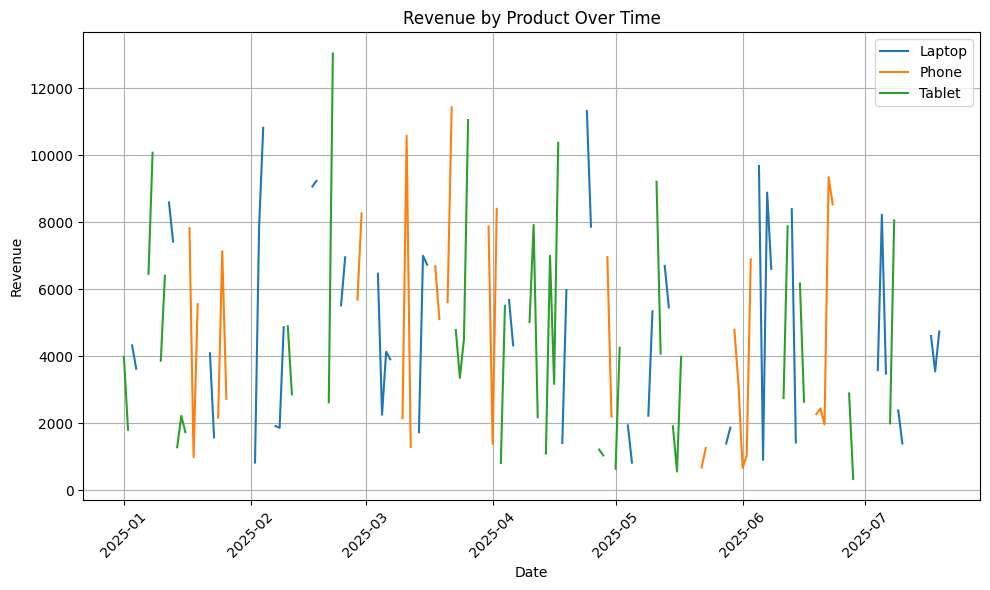

In [29]:
#Compare revenue between products over time - multi-line chart
revenue_by_product = df.groupby(['date', 'product'])['revenue'].sum().unstack()

plt.figure(figsize=(10, 6))
for product in revenue_by_product.columns:
    plt.plot(revenue_by_product.index, revenue_by_product[product], label=product)
plt.title('Revenue by Product Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### 6. Revenue according to customer_type (Draw boxplot, seaborn).

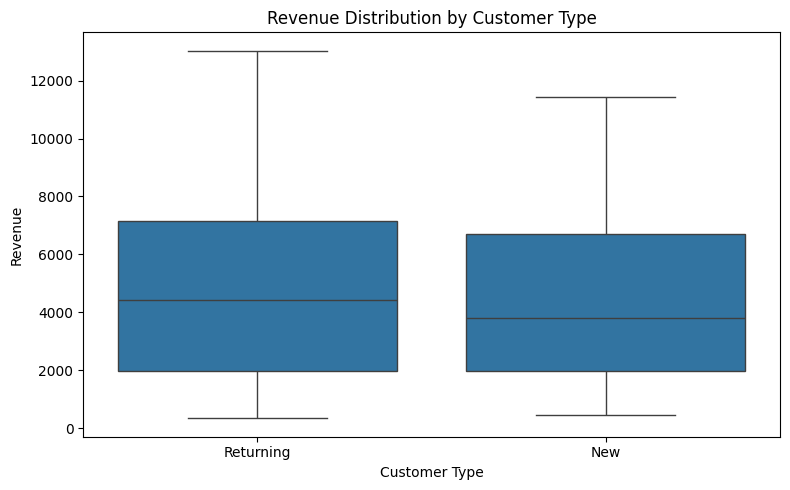

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='customer_type', y='revenue', data=df)
plt.title('Revenue Distribution by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

### 7. Draw scatter plot: price vs quantity.

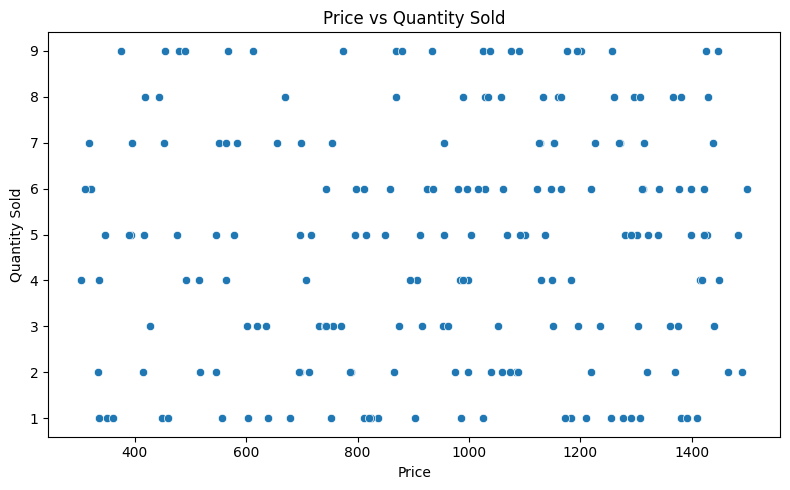

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='price', y='quantity', data=df)
plt.title('Price vs Quantity Sold')
plt.xlabel('Price')
plt.ylabel('Quantity Sold')
plt.tight_layout()
plt.show()

### 8. Draw a Heatmap correlation

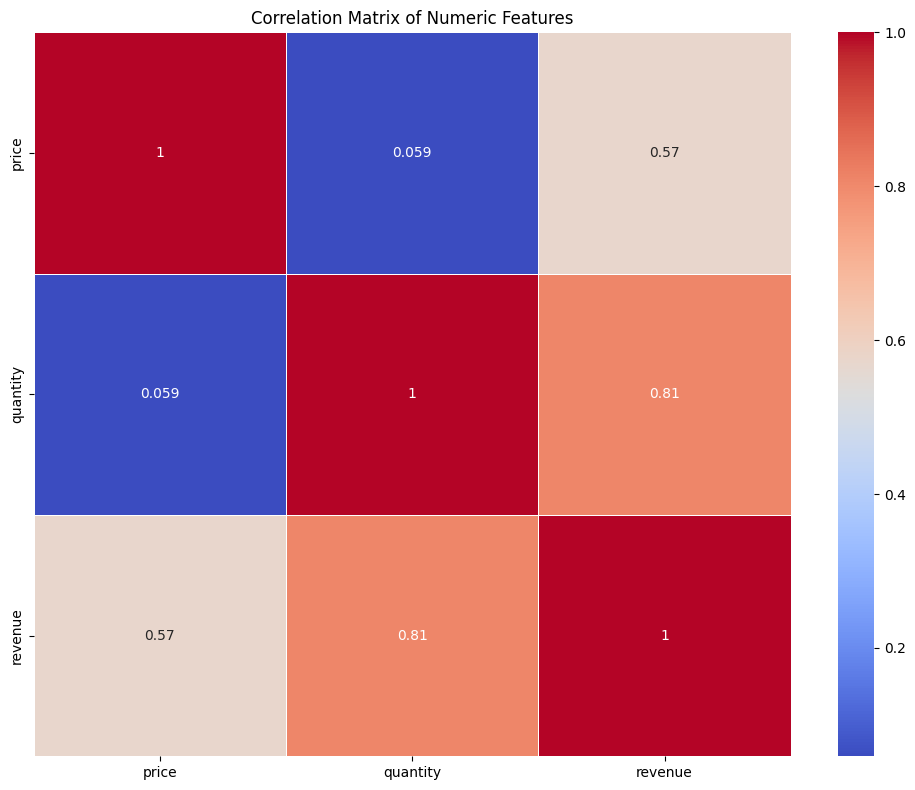

In [32]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

### 9. Drawing Subplots

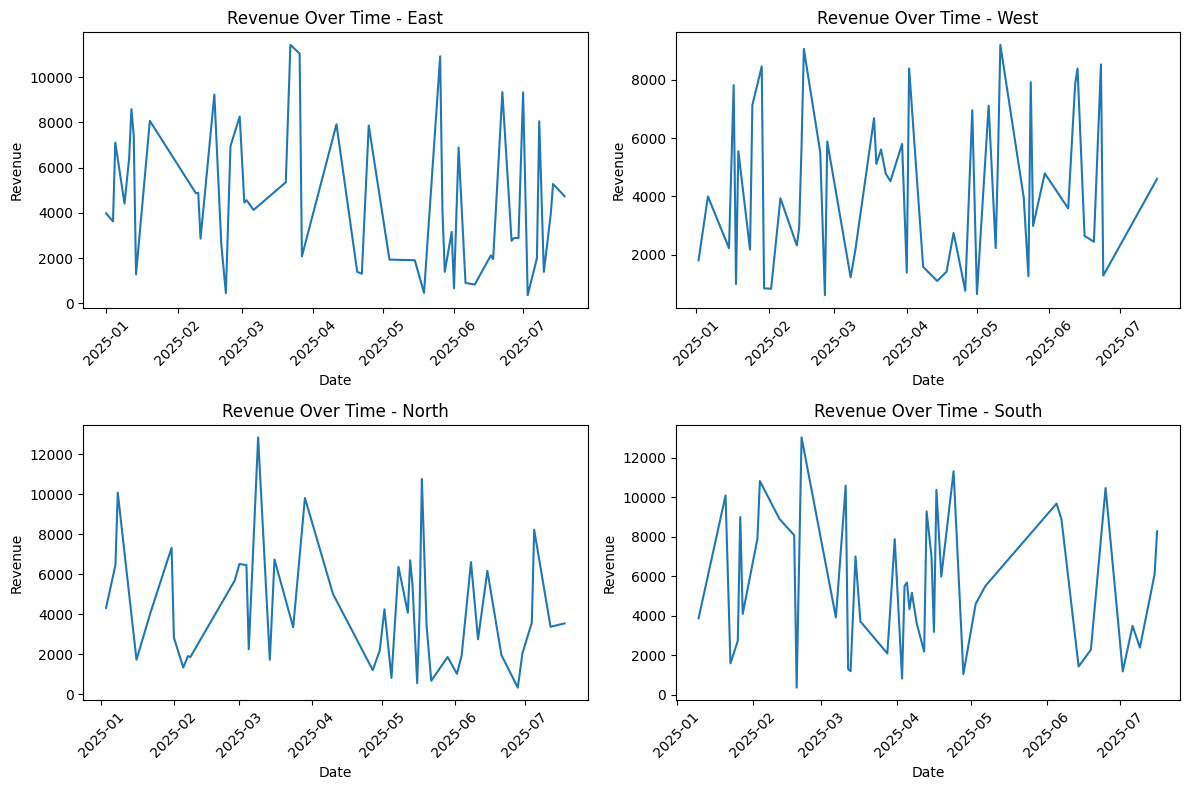

In [33]:
#Subplot of revenue by region
regions = df['region'].unique()
plt.figure(figsize=(12, 8))
for i, region in enumerate(regions):
    plt.subplot(2, 2, i+1)
    region_data = df[df['region'] == region]
    revenue_over_time = region_data.groupby('date')['revenue'].sum()
    plt.plot(revenue_over_time.index, revenue_over_time.values)
    plt.title(f'Revenue Over Time - {region}')
    plt.xlabel('Date')
    plt.ylabel('Revenue')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

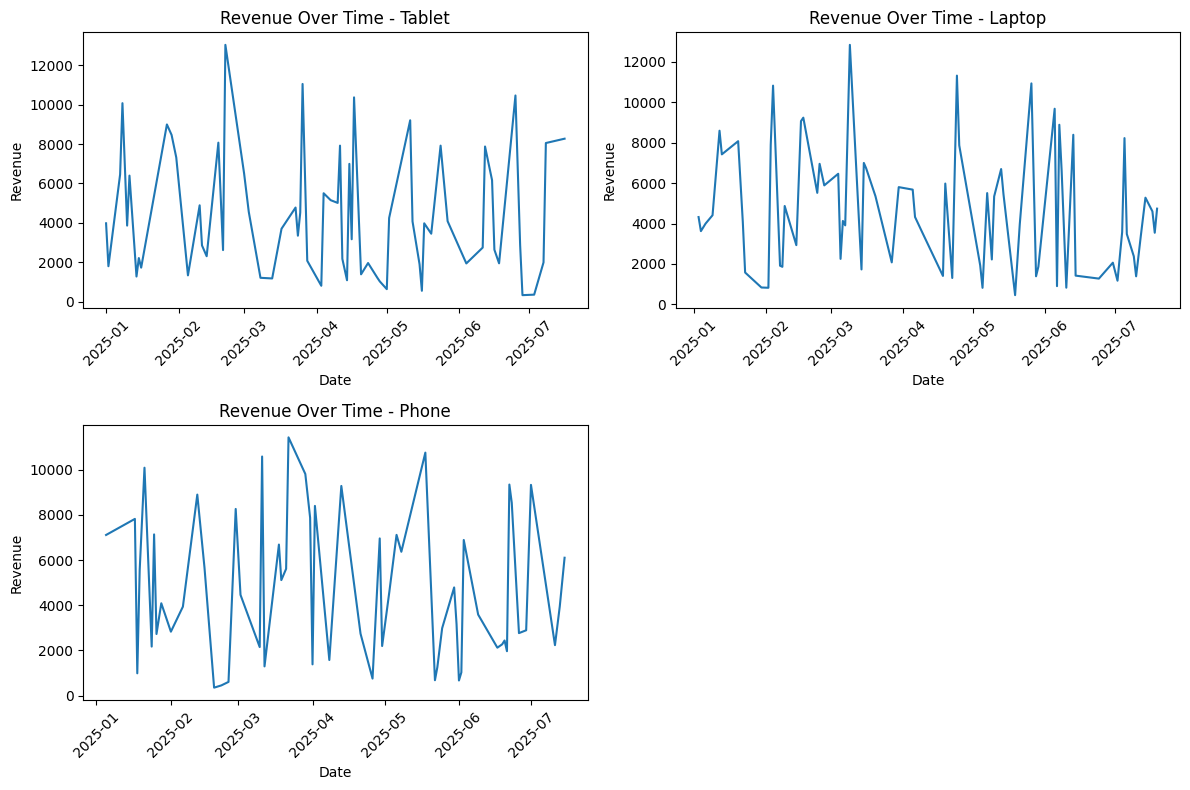

In [34]:
# Subplot of revenue according by product
products = df['product'].unique()
plt.figure(figsize=(12, 8))
for i, product in enumerate(products):
    plt.subplot(2, 2, i+1)
    product_data = df[df['product'] == product]
    revenue_over_time = product_data.groupby('date')['revenue'].sum()
    plt.plot(revenue_over_time.index, revenue_over_time.values)
    plt.title(f'Revenue Over Time - {product}')
    plt.xlabel('Date')
    plt.ylabel('Revenue')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 10. Analysis

In [ ]:
# Which region sells best? 
best_selling_region = revenue_by_region.idxmax()
print(f"The best selling region is: {best_selling_region}")

#Which product has the highest profit?
hightest_profit_product = df.groupby('product')['revenue'].sum().idxmax()
print(f"The product with the highest profit is: {hightest_profit_product}")

The best selling region is: South
The product with the highest profit is: Laptop
